In [1]:
import os
import torch
from torchvision import datasets, transforms, utils
import torchvision.models as models
import torch.nn as nn

from torch.utils.data import DataLoader,Subset
import numpy as np
import matplotlib.pyplot as plt


In [2]:
data_dir = 'images/'  # replace with the path to your main image folder
wiki_dir = os.path.join(data_dir, 'wiki')
insight_dir = os.path.join(data_dir, 'insight')
inpainting_dir = os.path.join(data_dir, 'inpainting')
text2img_dir = os.path.join(data_dir, 'tex2img')

In [3]:
'''
import shutil

def flatten_directory(directory):
    for root, subdirs, files in os.walk(directory, topdown=False):
        for file in files:
            # Construct the path to the file in the subdirectory
            subfile_path = os.path.join(root, file)
            # Construct the path to where the file needs to be moved (main directory)
            mainfile_path = os.path.join(directory, file)
            # Move the file to the main directory
            shutil.move(subfile_path, mainfile_path)
        # If the current directory is not the main directory, remove it after moving its files
        if root != directory:
            os.rmdir(root)


# Flatten both 'real' and 'fake' directories
flatten_directory(inpainting_dir)
flatten_directory(text2img_dir)
'''

"\nimport shutil\n\ndef flatten_directory(directory):\n    for root, subdirs, files in os.walk(directory, topdown=False):\n        for file in files:\n            # Construct the path to the file in the subdirectory\n            subfile_path = os.path.join(root, file)\n            # Construct the path to where the file needs to be moved (main directory)\n            mainfile_path = os.path.join(directory, file)\n            # Move the file to the main directory\n            shutil.move(subfile_path, mainfile_path)\n        # If the current directory is not the main directory, remove it after moving its files\n        if root != directory:\n            os.rmdir(root)\n\n\n# Flatten both 'real' and 'fake' directories\nflatten_directory(inpainting_dir)\nflatten_directory(text2img_dir)\n"

In [4]:
        
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize all images to 224x224 for ResNet
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet stats
])


In [5]:
img_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

In [6]:
# This will print the mapping of class names to their respective labels
print(img_dataset.class_to_idx)

{'inpainting': 0, 'insight': 1, 'text2img': 2, 'wiki': 3}


In [7]:
img_dataset

Dataset ImageFolder
    Number of datapoints: 120000
    Root location: images/
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [15]:
from torch.utils.data import random_split

# Define the size of the subset
subset_size = 10000

# Generate random indices for the subset
indices = np.random.permutation(len(img_dataset))[:subset_size]
subset_dataset = Subset(img_dataset, indices)


# Assuming 'dataset' is already loaded using ImageFolder
total_images = len(subset_dataset)
train_size = int(0.8 * total_images)
test_size = total_images - train_size

train_dataset, test_dataset = random_split(subset_dataset, [train_size, test_size])


In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)


Batch labels: tensor([2, 0, 3, 2, 1, 2, 0, 0, 0, 3, 0, 0, 0, 1, 3, 2, 2, 1, 0, 2, 1, 1, 0, 0,
        3, 0, 3, 1, 3, 2, 3, 2])


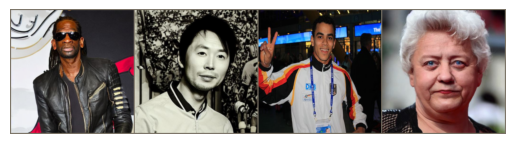

In [17]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')
    
# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
print("Batch labels:", labels) 

# Displaying images
imshow(utils.make_grid(images[:4]))
plt.show()

In [18]:
# Load a pre-trained ResNet model
model = models.resnet50(pretrained=True)

# Freeze all layers in the network
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# Original ResNet50 outputs 1000 classes, changing it to 4 for your dataset
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)

# Transfer the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
# Cross entropy loss for classification
criterion = nn.CrossEntropyLoss()

# Only optimize the parameters of the final layer
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


In [20]:
import time

# Define the number of epochs
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    start_time = time.time()
    for i, (inputs, labels) in enumerate(train_loader, 0):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # Log every 10 batches
        if i % 10 == 9:
            print(f'Epoch {epoch + 1}, Batch {i + 1}, Loss: {running_loss / 10:.4f}')
            running_loss = 0.0

    epoch_time = time.time() - start_time
    print(f'Epoch {epoch + 1} completed in {epoch_time:.2f} seconds')


Epoch 1, Batch 10, Loss: 1.4706
Epoch 1, Batch 20, Loss: 1.3352
Epoch 1, Batch 30, Loss: 1.2599
Epoch 1, Batch 40, Loss: 1.2626
Epoch 1, Batch 50, Loss: 1.1926
Epoch 1, Batch 60, Loss: 1.1784
Epoch 1, Batch 70, Loss: 1.1707
Epoch 1, Batch 80, Loss: 1.1441
Epoch 1, Batch 90, Loss: 1.1082
Epoch 1, Batch 100, Loss: 1.1221
Epoch 1, Batch 110, Loss: 1.1061
Epoch 1, Batch 120, Loss: 1.0652
Epoch 1, Batch 130, Loss: 1.0657
Epoch 1, Batch 140, Loss: 1.1037
Epoch 1, Batch 150, Loss: 1.0896
Epoch 1, Batch 160, Loss: 1.0513
Epoch 1, Batch 170, Loss: 1.1332
Epoch 1, Batch 180, Loss: 1.1267
Epoch 1, Batch 190, Loss: 1.0518
Epoch 1, Batch 200, Loss: 1.0468
Epoch 1, Batch 210, Loss: 0.9719
Epoch 1, Batch 220, Loss: 1.0583
Epoch 1, Batch 230, Loss: 1.0535
Epoch 1, Batch 240, Loss: 1.1366
Epoch 1, Batch 250, Loss: 1.0096
Epoch 1 completed in 904.22 seconds
Epoch 2, Batch 10, Loss: 0.9911
Epoch 2, Batch 20, Loss: 1.0183
Epoch 2, Batch 30, Loss: 0.9583
Epoch 2, Batch 40, Loss: 1.0033
Epoch 2, Batch 50, L

In [21]:
# Example testing loop
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the test images: {100 * correct / total}%')

Accuracy of the model on the test images: 61.5%
